# znfuel against cimp
Investigate what happens to fuel ion density as impurities increase.

In [16]:
import numpy as np
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
from IPython.display import clear_output
from process.main import SingleRun
from pathlib import Path
import process
from scipy.stats import qmc

In [17]:
fws = np.linspace(5e-6, 1e-4, 10)

input_file = "failing_ivp_eval_IN.DAT"
fuel_ions = []
for fw in fws:
    single_run = SingleRun(input_file)
    process.data_structure.physics_variables.triang = 0.5
    process.data_structure.impurity_radiation_module.f_nd_impurity_electron_array[
        13
    ] = fw
    single_run.run()
    fuel_ions.append(
        process.data_structure.physics_variables.nd_plasma_fuel_ions_vol_avg
    )
    clear_output()


Text(0.5, 1.0, 'Fuel ion density against tungsten fraction')

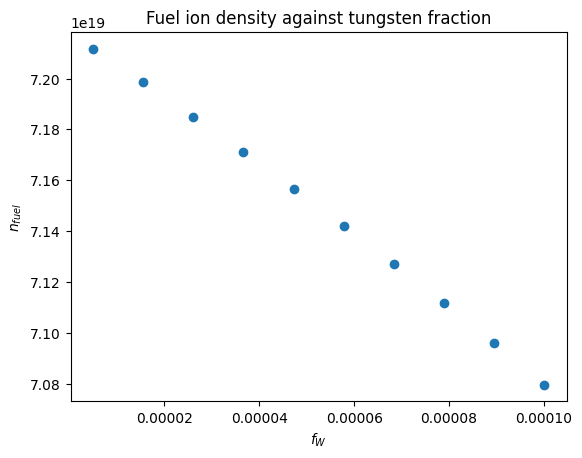

In [18]:
# %matplotlib inline
fig, ax = plt.subplots()
ax.scatter(fws, fuel_ions)
ax.set_xlabel("$f_W$")
ax.set_ylabel("$n_{fuel}$")
ax.set_title("Fuel ion density against tungsten fraction")